In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("cardiotocographic.csv")
df.head()
df.info()
df.shape
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [4]:
df.fillna(df.mean(), inplace=True)

print("After cleaning:")
print(df.isnull().sum())

After cleaning:
LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


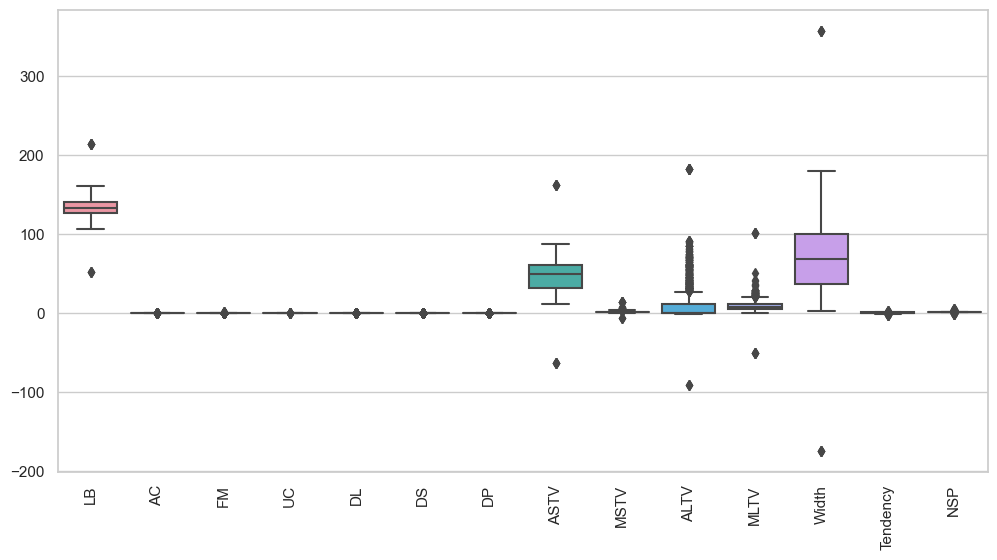

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [6]:
df.describe()
df.median()
df.std()
df.quantile(0.25)
df.quantile(0.75)

LB          140.000000
AC            0.005606
FM            0.002567
UC            0.006536
DL            0.003289
DS            0.000000
DP            0.000000
ASTV         61.000000
MSTV          1.700000
ALTV         11.000000
MLTV         10.800000
Width       100.000000
Tendency      1.000000
NSP           1.000000
Name: 0.75, dtype: float64

In [7]:
# Outlier Treatment using IQR method
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outlier treatment completed")

Outlier treatment completed


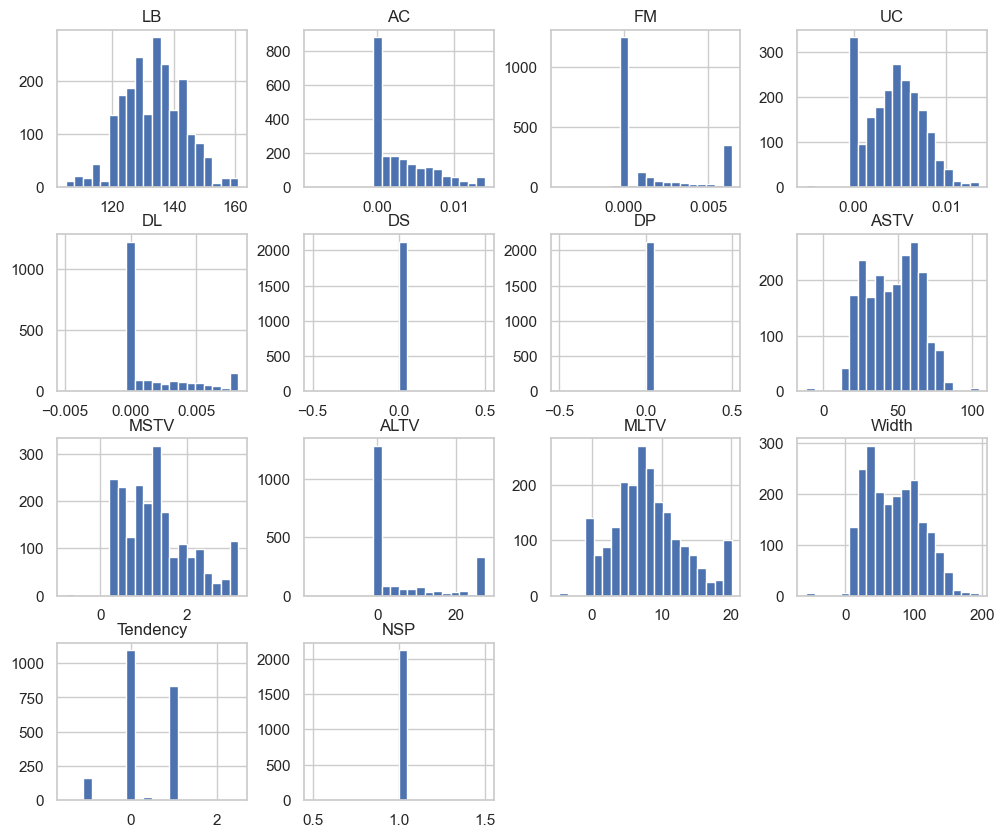

In [8]:
#Histograms
df.hist(figsize=(12,10), bins=20)
plt.show()

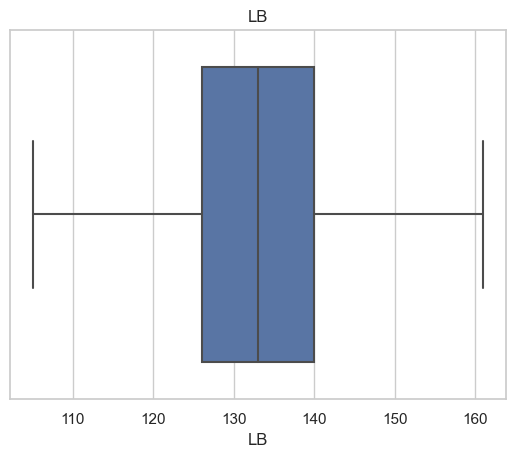

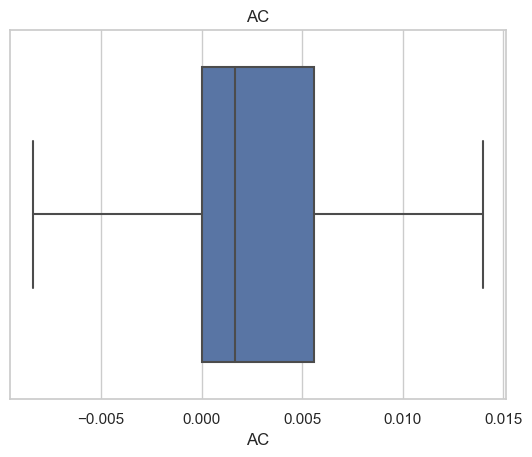

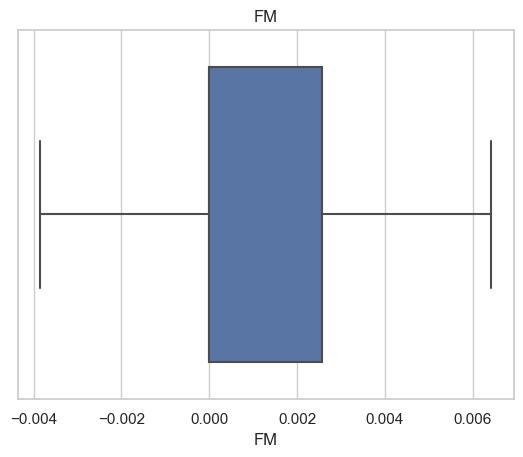

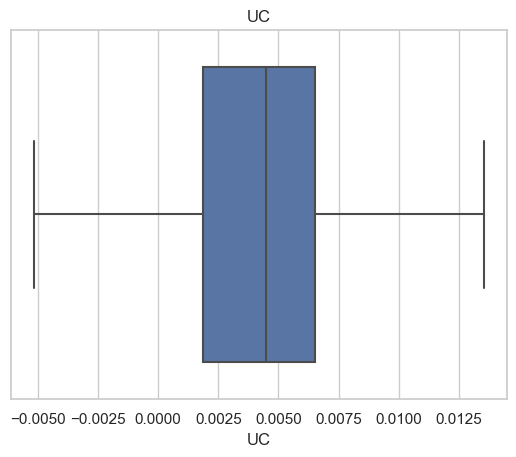

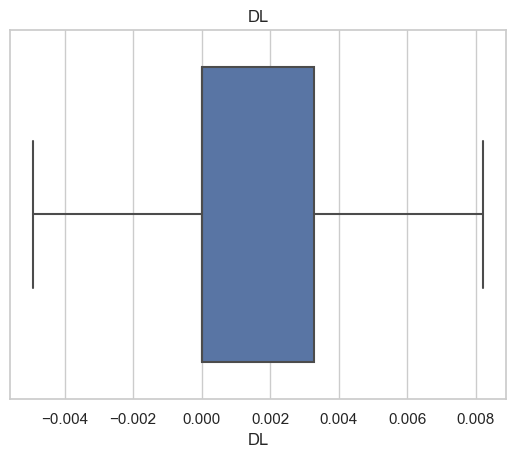

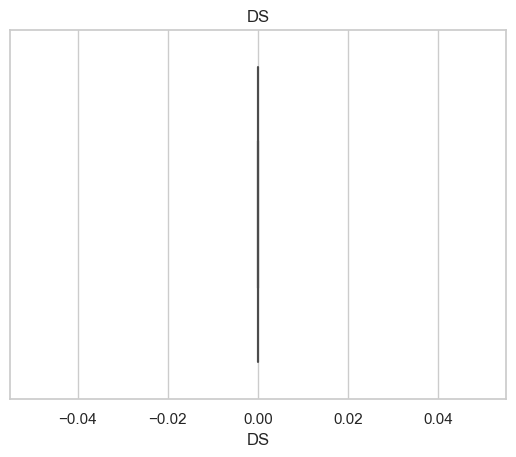

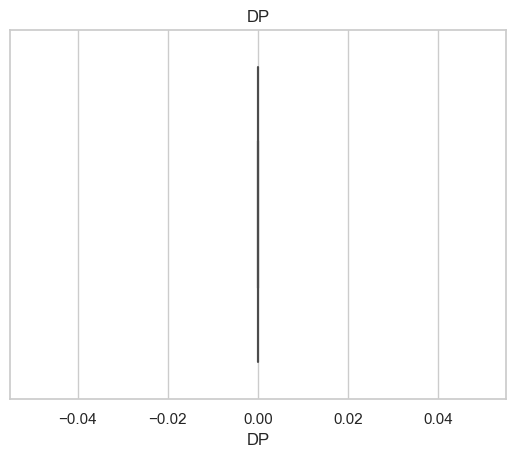

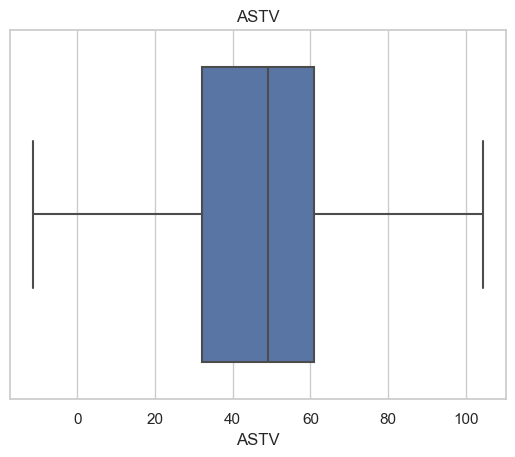

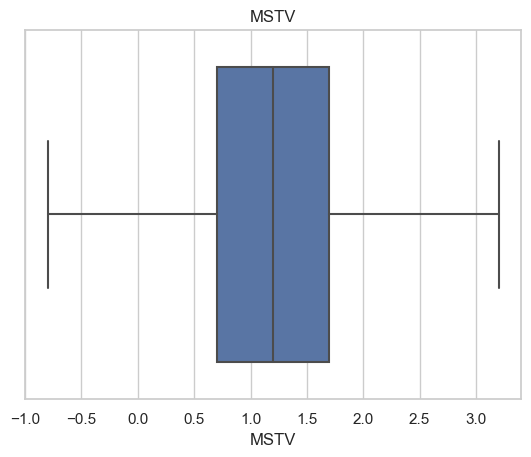

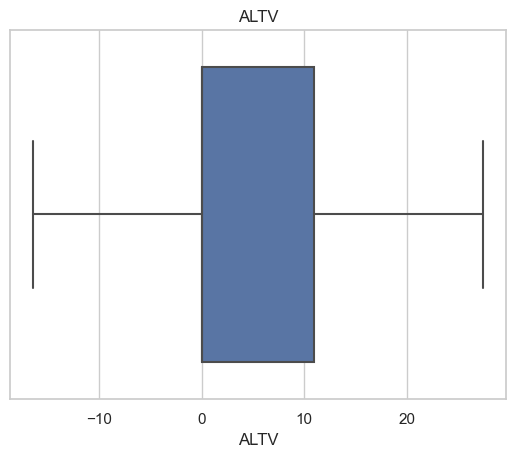

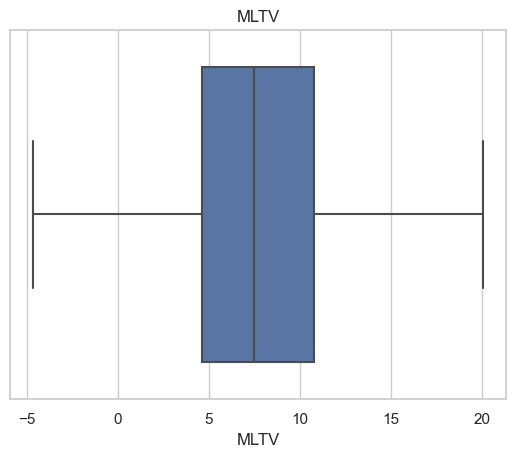

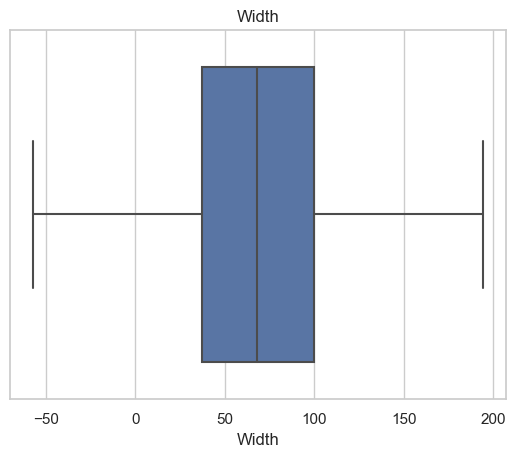

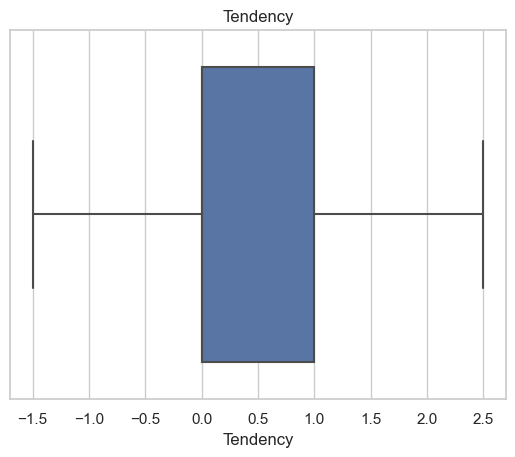

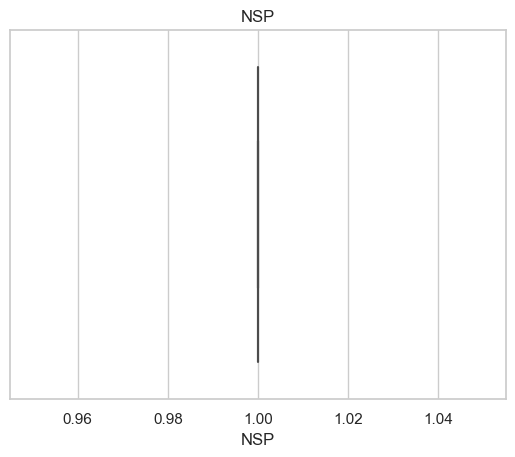

In [9]:
#Boxplot
for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

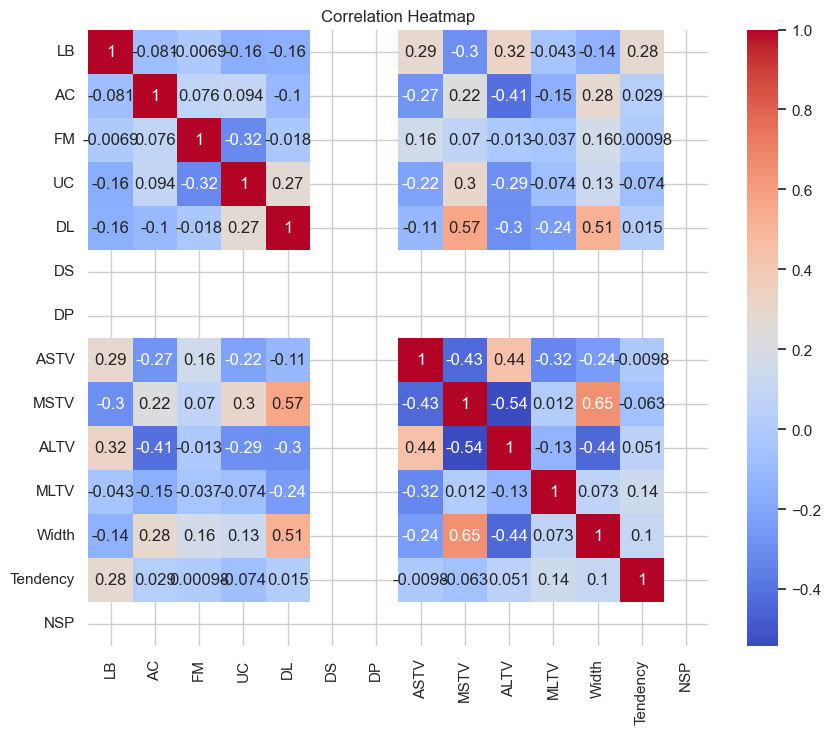

In [10]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

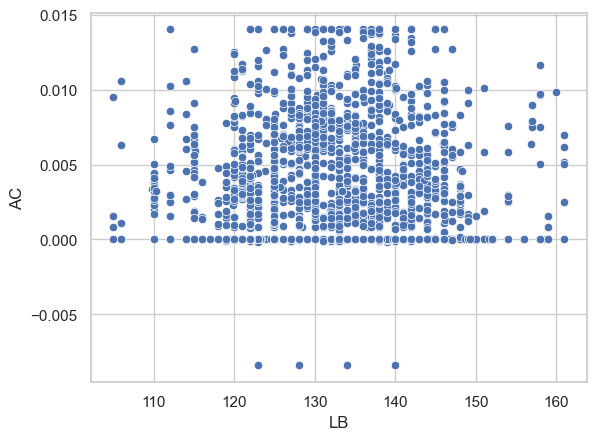

In [11]:
#Scatter plot
sns.scatterplot(x='LB', y='AC', data=df)
plt.show()

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


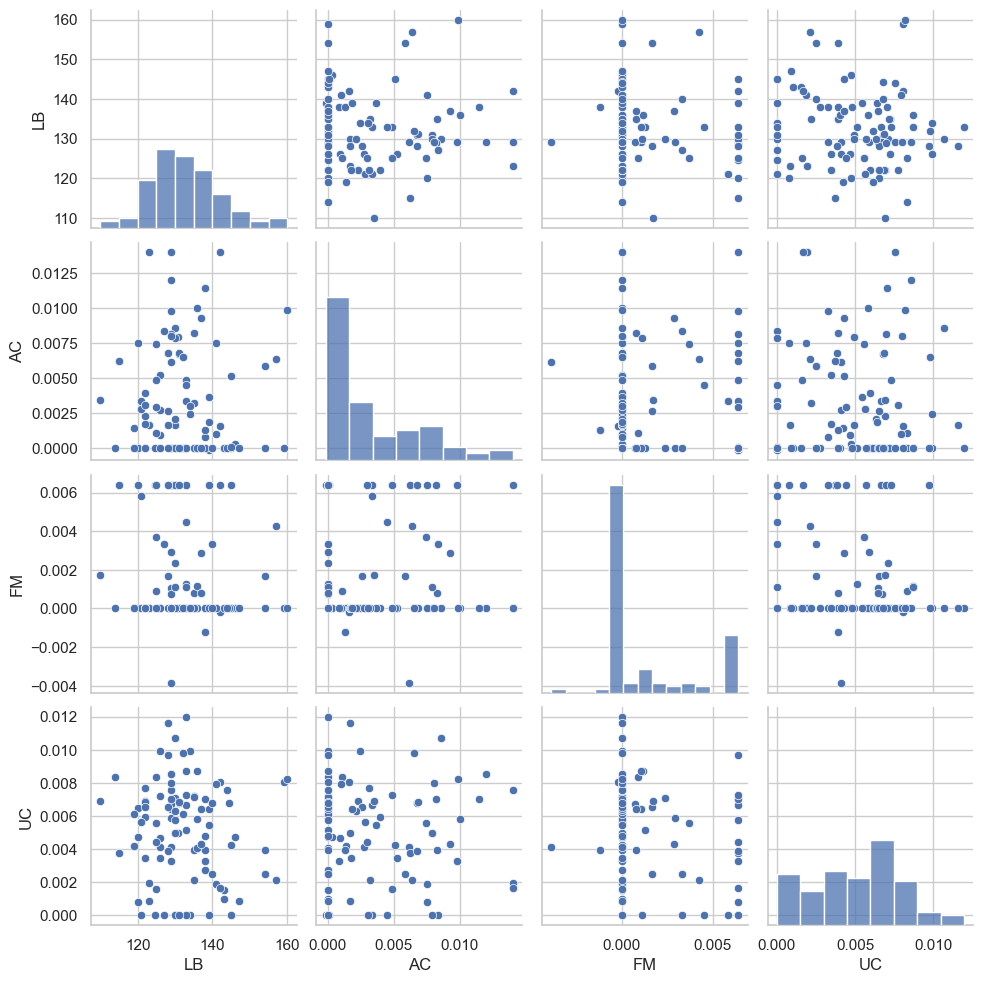

In [12]:
df = df.dropna()
sample_df = df[['LB','AC','FM','UC']].sample(min(100, len(df)))
sns.pairplot(sample_df, diag_kind='hist')
plt.show()

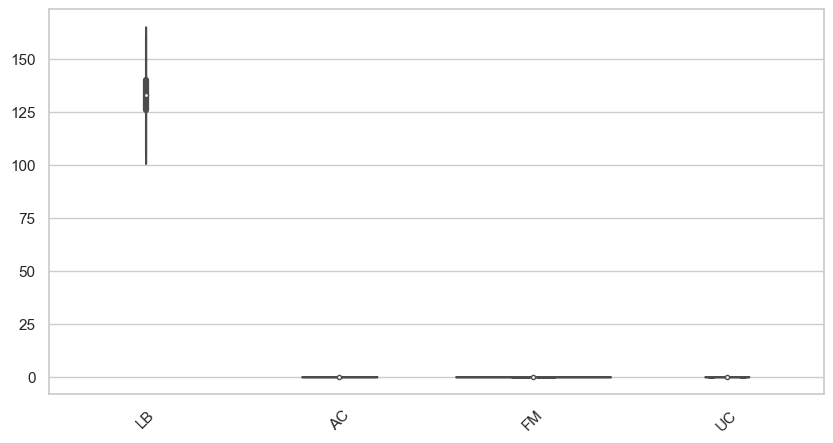

In [13]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df[['LB','AC','FM','UC']])
plt.xticks(rotation=45)
plt.show()

In [14]:
corr = df.corr()
corr['LB'].sort_values(ascending=False)

LB          1.000000
ALTV        0.322315
ASTV        0.285623
Tendency    0.281012
FM         -0.006904
MLTV       -0.042613
AC         -0.080880
Width      -0.140044
DL         -0.156224
UC         -0.162773
MSTV       -0.295485
DS               NaN
DP               NaN
NSP              NaN
Name: LB, dtype: float64